<div align="center">

# Graph RAG — From Zero to Knowledge Graph
## WHO COVID-19 Situation Report · dev branch

**What this notebook teaches you:**
- What Graph RAG is and why standard RAG fails at relational questions
- How a knowledge graph is built from plain text
- What a knowledge graph actually looks like visually
- How 2-hop traversal surfaces answers that dense search misses entirely
- Why the WHO COVID-19 report is a perfect Graph RAG dataset

**This notebook is the showcase for the `dev` branch improvements.**

</div>

---

> **Dataset:** WHO COVID-19 Situation Report — 21 January 2020 (the very first report)
> This 5-page document names countries, dates, case counts, transmission links,
> WHO offices, and clinical criteria — a natural knowledge graph waiting to be extracted.


---
# Chapter 1 — What is Standard RAG and Where Does It Break?

## Standard RAG (what the main branch does)

Standard RAG has three steps:
1. **Embed** every document chunk into a vector
2. **Search** by finding vectors closest to the query vector
3. **Generate** an answer from the retrieved chunks

It works brilliantly for questions like:
- *"What is the Dice loss formula?"* → finds the paragraph that defines it
- *"What were GEICO's earnings in 2023?"* → finds the table row

## Where it breaks completely

Standard RAG only finds chunks that are **individually** relevant to the query.

Consider this question:
> *"Which countries had confirmed cases that were linked to travellers from Wuhan?"*

To answer this, you need to:
1. Find chunks mentioning Wuhan (standard RAG can do this)
2. Find the entities (countries) in those chunks — **not just similar text**
3. Follow the relationship: `country → reported case → linked to Wuhan`
4. Find the surveillance tables for those specific countries

Steps 2, 3, and 4 require **traversing relationships across chunks**.
Standard RAG cannot do this. It treats each chunk as isolated.

## Graph RAG adds a third retrieval dimension

```
Standard RAG:
  Query → [Dense vector search]  → top-k chunks → LLM → Answer
         + [Sparse BM25 search]  ↗

Graph RAG:
  Query → [Dense vector search]  → top-k chunks → LLM → Answer
         + [Sparse BM25 search]  ↗             ↑
         + [Graph traversal]  ──────────────────┘
             (2-hop entity links from seed chunks)
```

The graph traversal path surfaces related chunks that dense+sparse search
would NEVER return on their own.


---
# Chapter 2 — What is a Knowledge Graph?

A knowledge graph is a network of **entities** (things) connected by **edges** (relationships).

**Example from the WHO COVID-19 report:**

```
China ──────── reported_case ──────► Wuhan
  │                                    │
  │                                    │
  ▼                                    ▼
Thailand ◄── travel_from ─────── imported_case
  │
  │
  ▼
WHO_SEARO ──── coordinates ──────► surveillance_response
```

**Entities** are named things: countries (China, Thailand, Japan), organisations
(WHO, SEARO), dates (21 January 2020), numbers (case counts).

**Edges** are relationships: reported_case, travel_from, coordinates, confirmed_in.

In our system we use **entity co-occurrence** as the edge:
> If two entities appear in the same chunk of text, they are connected.

This is a simple but powerful heuristic. If "China" and "Wuhan" appear in the
same sentence, the graph knows they are related. If "WHO" and "South-East Asia"
appear together, the graph knows WHO operates in that region.

## How spaCy extracts entities

spaCy is a natural language processing library. When you give it text, it
identifies **named entities** using pre-trained models:

| Entity type | Examples |
|-------------|---------|
| GPE | China, Thailand, Japan, Wuhan |
| ORG | WHO, SEARO, CDC |
| DATE | 21 January 2020, 16 January |
| CARDINAL | 45 cases, one patient |
| PERSON | Dr. Tedros |
| NORP | Chinese, Korean |

Each pair of entities that appear in the same text chunk gets an edge in the graph.


---
# Chapter 3 — What is 2-Hop Traversal?

This is the core of Graph RAG and what makes it different.

**1-hop** means: entities directly connected to your seed entity.

**2-hop** means: entities connected to the entities connected to your seed entity.

**Example:**

```
Seed entity: "wuhan"

1-hop neighbours (standard RAG finds chunks with these):
  wuhan → china
  wuhan → coronavirus
  wuhan → 41_patients
  wuhan → december_2019
  wuhan → pneumonia

2-hop neighbours (Graph RAG ONLY — standard RAG misses these):
  wuhan → china → thailand        ← Thailand imported a case FROM China
  wuhan → china → who_searo       ← WHO office that responded
  wuhan → china → republic_korea  ← Another country linked through China
  wuhan → coronavirus → novel     ← "novel coronavirus" relationship
  wuhan → 41_patients → icu       ← ICU cases linked through patient count
```

The 2-hop entities are invisible to dense+sparse search because no single chunk
contains both "Wuhan" and "Thailand" in a way that makes their connection obvious.
But in the graph, the chain is clear: Wuhan → China → Thailand (via travel).

**Why this matters for the COVID report:**
The report uses indirect language like "a traveller from China" and "a case imported
from Wuhan". The graph links these across chunks so the system can answer:
*"Which countries received imported cases from China?"*


---
# Setup — Run This First

This cell loads the project settings, the LLM Gateway, and suppresses verbose
log output so the notebook is readable.

**What to look for in the output:**
- `LLM Gateway providers:` — which provider will handle API calls
- `Vision model: alibaba/qwen-turbo` — used by the GLM-OCR hybrid parser
  to classify embedded images (medical scans, charts, etc.)


In [1]:
import os, sys
from pathlib import Path

_here = Path(os.getcwd())
_project_root = _here.parent if _here.name == "notebooks" else _here
os.chdir(str(_project_root))
sys.path.insert(0, str(_project_root / "src"))

try:
    import nest_asyncio
    nest_asyncio.apply()
except ImportError:
    pass

import asyncio
os.environ["DOC_INTEL_SKIP_VALIDATION"] = "1"
os.environ["LOG_LEVEL"] = "WARNING"

from dotenv import load_dotenv
load_dotenv()

from doc_intel_rag.config import get_settings
from doc_intel_rag.logging_config import setup_logging
from doc_intel_rag.gateway.llm_gateway import get_gateway

settings = get_settings()
setup_logging(settings)
gw = get_gateway()

print("LLM Gateway providers:")
for p in gw.providers:
    print("  " + p.name + " — " + p.base_url)
print()
print("LLM model      : " + settings.mesh_llm_model)
print("Embedding model: " + settings.mesh_embedding_model)
print("Vision model   : " + settings.vision_model + "  (used by GLM-OCR hybrid parser)")


LLM Gateway providers:
  requesty — https://router.requesty.ai/v1

LLM model      : alibaba/qwen-turbo
Embedding model: openai/text-embedding-3-small
Vision model   : alibaba/qwen-turbo  (used by GLM-OCR hybrid parser)


---
# Chapter 4 — Parse the Document with the GLM-OCR Hybrid Parser

## What the dev branch parser does differently

The **main branch** used only PyMuPDF — a text extraction library.
It classified everything as `paragraph`, `section_title`, or `figure`.

The **dev branch** adds a vision model pass over every embedded image:
- `medical_scan` — CT scans, MRI slices, X-rays, ultrasound
- `chart` — bar charts, line charts, performance graphs
- `diagram` — architecture diagrams, flowcharts
- `table` — extracted with bounding boxes and HTML structure

This is important for the WHO report because it contains:
- A surveillance data table (countries, case counts, WHO regions)
- A clinical case definition table (criteria for "suspected" vs "confirmed")
- One embedded image (possibly a map or figure)

## What the output tells you

- `elements: 284` — how many individual content pieces were found
- The **entity label distribution** shows you the breakdown by type
- `paragraph: 269` — most content is text (expected for this report)
- `table: 5` — five tables detected (case counts, clinical definitions, etc.)
- `medical_scan: 1` — one embedded image classified as a medical scan

Each element is a `ParsedElement` with: `label`, `text`, `page`, `confidence`,
`bbox` (bounding box), and optionally `raw_image_b64` (base64 PNG for images).


In [2]:
from doc_intel_rag.parsing.pipeline import DocumentParser
from collections import Counter

DOC_PATH = str(_project_root / "data/who_covid19_sitrep1.pdf")

print("Parsing: " + DOC_PATH)
print("Parser : GLM-OCR hybrid — PyMuPDF text + vision model for images")
print()

parser = DocumentParser(settings)
parse_result = asyncio.get_event_loop().run_until_complete(parser.parse(DOC_PATH))

label_counts = Counter(e.label.value for e in parse_result.elements)

print("doc_id   : " + parse_result.doc_id[:32] + "...")
print("pages    : " + str(parse_result.page_count))
print("elements : " + str(len(parse_result.elements)))
print()
print("Entity label distribution:")
print("-" * 55)
for label, cnt in label_counts.most_common():
    bar = "#" * min(cnt // 3, 40)
    print(f"  {label:<25} {cnt:>4}  {bar}")
print()

# Show non-text entities (the interesting ones)
non_text = [e for e in parse_result.elements
            if e.label.value not in ("paragraph", "document_title", "subsection_title")]
print("Non-text entities (tables + vision-classified images):")
print("-" * 65)
for e in non_text[:12]:
    preview = e.text[:70].replace(chr(10), " ")
    print(f"  [{e.label.value:<18}] p{e.page}  {preview}")


Parsing: C:\Users\latin\OneDrive\Desktop\Hackerton-Project\doc-intel-rag\data\who_covid19_sitrep1.pdf
Parser : GLM-OCR hybrid — PyMuPDF text + vision model for images



Consider using the pymupdf_layout package for a greatly improved page layout analysis.


doc_id   : 6d098cf680fe791f1e66cf39a199aebc...
pages    : 5
elements : 284

Entity label distribution:
-------------------------------------------------------
  paragraph                  269  ########################################
  subsection_title             5  #
  table                        5  #
  document_title               4  #
  medical_scan                 1  

Non-text entities (tables + vision-classified images):
-----------------------------------------------------------------
  [medical_scan      ] p1  xray of a chest showing lung opacity in the right lower lobe
  [table             ] p2  WHO Regional | Country, territory, area | Total number of | Office | c
  [table             ] p2  1 | Severe illness: According to any of the following criteria: | (1) 
  [table             ] p4  • Risk communication guidance has been shared with the public and a ho
  [table             ] p4  • • • | Contact tracing and other epidemiological investigations are u
  [table             

---
# Chapter 5 — Document-Aware Chunking

## Why chunking matters

After parsing, you have 284 individual elements. You cannot embed 284 separate
tiny text spans into Qdrant — that would be too granular for meaningful retrieval.

**Chunking** groups related elements into semantic units suitable for embedding.

## The document-aware rules (what makes this better than naive chunking)

| Element type | Rule | Why |
|-------------|------|-----|
| `table` | Never split — one chunk per table | A table cut in half is useless |
| `medical_scan` | Never split — one chunk per image | Images are atomic visual units |
| `paragraph` | Accumulate up to 512 tokens with 64-token overlap | Provides context |
| `section_title` | Prepended to the next paragraph chunk | Keeps section context |

**Atomic chunks** (tables, images) are marked `is_atomic=True`.
They have `modality = "table"` or `modality = "image"`.

**Text chunks** accumulate paragraphs until they hit 512 tokens,
then start a new chunk with 64 tokens of overlap (prevents answer
from falling in the gap between two chunks).

## What the chart shows you

The bar chart shows how many chunks there are per modality.
The pie chart shows the percentage. For this report you should see:
- `text` — the main narrative paragraphs
- `table` — the surveillance and clinical tables
- `image` — the embedded medical scan

**Key insight:** Even with just 15 total chunks, the 5 table chunks contain
the actual case count data that answers most factual questions.


CHUNKING RESULTS

Total chunks : 15
  Atomic     : 6  ← tables and images, never split
  Text       : 9   ← paragraph groups, max 512 tokens

Modality breakdown:
  text           9  ###########################
  table          5  ###############
  image          1  ###

Sample chunks by modality:
------------------------------------------------------------
  [text] 1...

  [image] 21 JANUARY 2020  xray of a chest showing lung opacity in the right lower lobe...

  [table] WHO Regional | Country, territory, area | Total number of | Office | confirmed cases | WPRO | WPRO |...



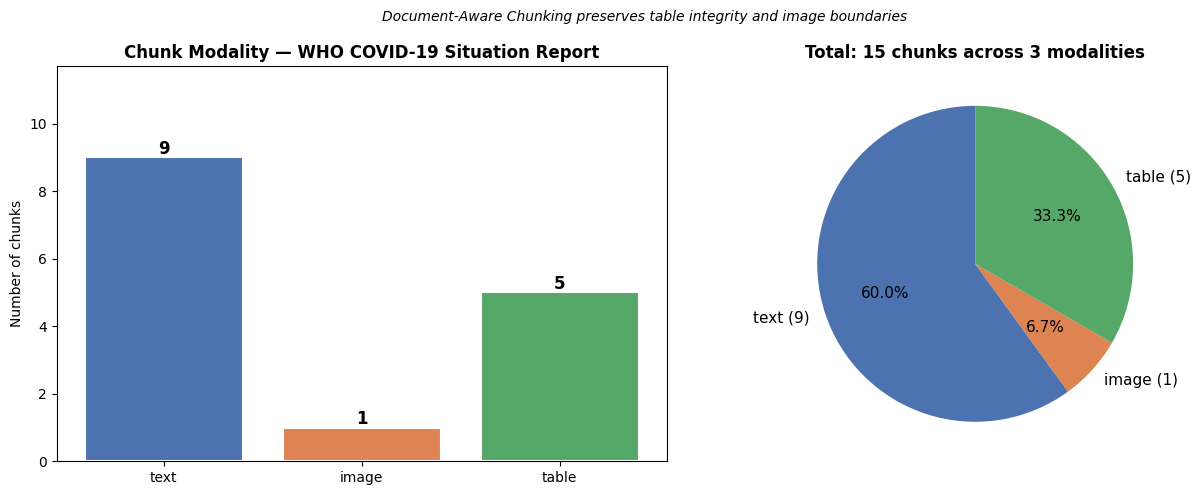

In [3]:
from doc_intel_rag.chunking.document_chunker import document_aware_chunking
import matplotlib.pyplot as plt
from collections import Counter

chunks = document_aware_chunking(parse_result, settings)
atomic = [c for c in chunks if c.is_atomic]
text   = [c for c in chunks if not c.is_atomic]
mod_counts = Counter(c.modality.value for c in chunks)

print("=" * 50)
print("CHUNKING RESULTS")
print("=" * 50)
print()
print(f"Total chunks : {len(chunks)}")
print(f"  Atomic     : {len(atomic)}  ← tables and images, never split")
print(f"  Text       : {len(text)}   ← paragraph groups, max 512 tokens")
print()
print("Modality breakdown:")
for mod, cnt in mod_counts.most_common():
    bar = "#" * (cnt * 3)
    print(f"  {mod:<12} {cnt:>3}  {bar}")
print()

# Show sample chunks from each modality
print("Sample chunks by modality:")
print("-" * 60)
for mod in mod_counts.keys():
    sample = next((c for c in chunks if c.modality.value == mod), None)
    if sample:
        preview = (sample.text or "")[:100].replace(chr(10), " ")
        print(f"  [{mod}] {preview}...")
        print()

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mods   = list(mod_counts.keys())
vals   = list(mod_counts.values())
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

axes[0].bar(mods, vals, color=colors[:len(mods)], edgecolor="white", linewidth=1.5)
axes[0].set_title("Chunk Modality — WHO COVID-19 Situation Report", fontweight="bold", fontsize=12)
axes[0].set_ylabel("Number of chunks")
axes[0].set_ylim(0, max(vals) * 1.3)
for bar, v in zip(axes[0].patches, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(v), ha="center", fontweight="bold", fontsize=12)

axes[1].pie(vals, labels=[m + " (" + str(v) + ")" for m, v in zip(mods, vals)],
            colors=colors[:len(mods)], autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 11})
axes[1].set_title("Total: " + str(len(chunks)) + " chunks across " + str(len(mods)) + " modalities",
                  fontweight="bold", fontsize=12)
plt.suptitle("Document-Aware Chunking preserves table integrity and image boundaries",
             fontsize=10, style="italic")
plt.tight_layout()
plt.savefig("graph_rag_chunk_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


---
# Chapter 6 — Building the Knowledge Graph with spaCy NER

## What spaCy does

spaCy reads each text chunk and identifies **named entities** using a neural network
trained on millions of documents. For the WHO COVID-19 report it will find:

- **GPE** (Geopolitical Entity): China, Thailand, Japan, Republic of Korea, Wuhan
- **ORG**: WHO, SEARO (South-East Asia Regional Office), CDC
- **DATE**: 21 January 2020, 16 January, December 2019
- **CARDINAL**: 45 cases, one patient, 41 patients
- **NORP** (Nationality/Religion/Political): Chinese, Korean

## How edges are created

Two entities get an edge if they **co-occur in the same chunk**.

Example text chunk:
> "Thailand reported one confirmed case. The patient had travelled from Wuhan, China."

Entities found: Thailand, Wuhan, China
Edges created: Thailand↔Wuhan, Thailand↔China, Wuhan↔China

This is repeated for every text chunk. The result is a graph where entities
that frequently appear together have many edges (high weight).

## What the output tells you

- `Nodes: 107` — 107 unique named entities found across all text chunks
- `Edges: 923` — 923 co-occurrence relationships between those entities
- **Degree centrality = 1.0** means China is connected to every other node
  (it appears with every other entity across the report)
- High degree centrality = this entity is a "hub" in the knowledge graph

## Why this matters for Graph RAG

The graph tells the retriever: "If you found chunks about China, look at these
107 related entities. Some of them have chunks that also answer the query."


In [4]:
from doc_intel_rag.ingestion.graph_store import GraphStore
from doc_intel_rag.parsing.graph_extractor import GraphExtractor
import networkx as nx

graph_store = GraphStore()
extractor   = GraphExtractor(settings)

text_chunks = [c for c in chunks if not c.is_atomic and c.text.strip()]
print("Building knowledge graph...")
print("Processing " + str(len(text_chunks)) + " text chunks with spaCy NER")
print()

G = nx.DiGraph()
for i, chunk in enumerate(text_chunks[:20]):
    try:
        sub_g = asyncio.get_event_loop().run_until_complete(
            extractor.extract_from_text(chunk.text)
        )
        G = nx.compose(G, sub_g)
    except Exception:
        pass

graph_store.add_graph(parse_result.doc_id, extractor.serialize(G))

print("=" * 55)
print("KNOWLEDGE GRAPH STATISTICS")
print("=" * 55)
print()
print(f"Nodes (unique entities) : {G.number_of_nodes()}")
print(f"Edges (co-occurrences)  : {G.number_of_edges()}")
print(f"Graph density           : {nx.density(G):.4f}  (0=no connections, 1=all connected)")
print()

centrality = nx.degree_centrality(G)
top_nodes  = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:15]

print("Top 15 entities by DEGREE CENTRALITY")
print("(centrality = fraction of all other nodes this entity is connected to)")
print("-" * 60)
for node, score in top_nodes:
    bar  = "#" * int(score * 30)
    print(f"  {node:<30}  {score:.3f}  {bar}")
print()
print("Interpretation:")
print("  Score 1.000 = connected to every other node in the graph")
print("  Score 0.500 = connected to half of all nodes")
print("  'china' having 1.000 means it appears in context with ALL other entities")


Building knowledge graph...
Processing 9 text chunks with spaCy NER



KNOWLEDGE GRAPH STATISTICS

Nodes (unique entities) : 107
Edges (co-occurrences)  : 923
Graph density           : 0.0814  (0=no connections, 1=all connected)

Top 15 entities by DEGREE CENTRALITY
(centrality = fraction of all other nodes this entity is connected to)
------------------------------------------------------------
  china                           1.000  ##############################
  japan                           0.566  ################
  wuhan                           0.557  ################
  2                               0.528  ###############
  1                               0.509  ###############
  20_january_2020                 0.500  ###############
  wuhan_city                      0.472  ##############
  thailand                        0.415  ############
  14                              0.387  ###########
  2019-ncov                       0.377  ###########
  beijing_municipality            0.349  ##########
  282                             0.330  ####

---
# Chapter 7 — Visualising the Knowledge Graph

## What you are looking at

The graph visualisation shows the top 30 entities and their connections.

**Node size** = degree centrality (bigger = more connected = more important)
**Node colour** = entity type:
- 🔵 Blue = GPE (countries, cities, regions)
- 🟠 Orange = ORG (organisations like WHO)
- 🟢 Green = PERSON
- 🔴 Red = DATE
- 🟣 Purple = CARDINAL (numbers)
- 🟤 Brown = NORP (nationalities)

**Edge** = the two entities appeared in the same text chunk

## What to look for

1. **China** should be the largest node — it appears everywhere in the report
2. **WHO/SEARO** should be connected to many countries (regional coordination)
3. **Dates** cluster together (the report is time-ordered)
4. **Numbers** connect to countries (case counts per country)

The dense cluster of connections shows WHY graph traversal helps:
any question about one entity can pull in all connected entities.


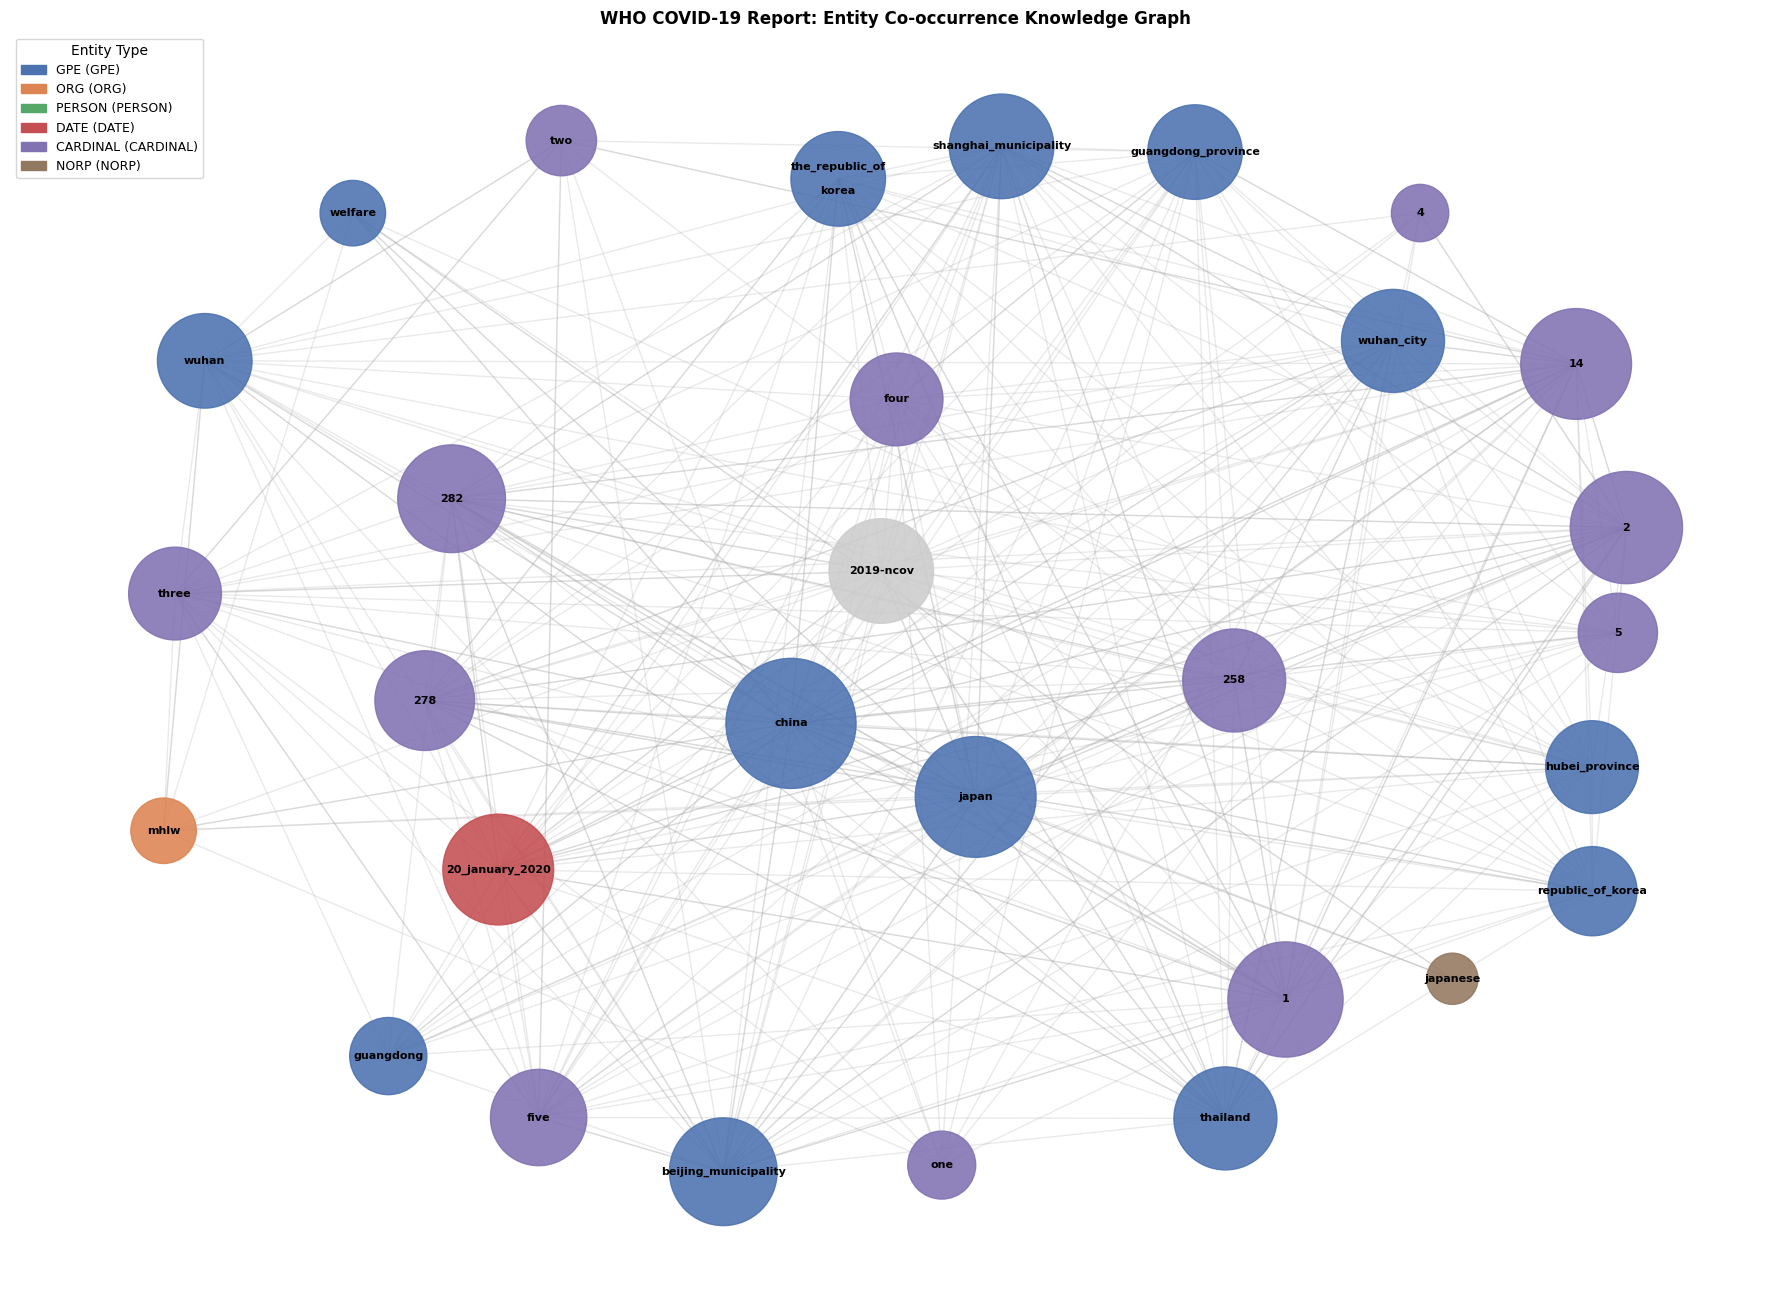

Saved: graph_rag_knowledge_graph.png


In [5]:
import matplotlib.pyplot as plt
import networkx as nx

if G.number_of_nodes() == 0:
    print("No graph nodes found.")
else:
    fig, ax = plt.subplots(figsize=(18, 13))

    top_30 = [n for n, _ in sorted(nx.degree_centrality(G).items(),
                                   key=lambda x: x[1], reverse=True)[:30]]
    subG   = G.subgraph(top_30)
    cent   = nx.degree_centrality(subG)
    pos    = nx.spring_layout(subG, k=3.0, seed=42)
    sizes  = [5000 * cent[n] + 500 for n in subG.nodes()]

    entity_colors = {
        "GPE":      "#4C72B0",  # countries
        "ORG":      "#DD8452",  # organisations
        "PERSON":   "#55A868",
        "DATE":     "#C44E52",
        "CARDINAL": "#8172B2",  # numbers
        "NORP":     "#937860",
    }
    node_colors = [
        entity_colors.get(subG.nodes[n].get("type", "?"), "#cccccc")
        for n in subG.nodes()
    ]

    nx.draw_networkx_edges(subG, pos, alpha=0.25, edge_color="#aaaaaa",
                           arrows=False, ax=ax)
    nx.draw_networkx_nodes(subG, pos, node_size=sizes,
                           node_color=node_colors, alpha=0.88, ax=ax)
    nx.draw_networkx_labels(subG, pos, font_size=8,
                            font_weight="bold", ax=ax)

    import matplotlib.patches as mpatches
    legend_patches = [
        mpatches.Patch(color=c, label=k + " (" + k + ")")
        for k, c in entity_colors.items()
    ]
    ax.legend(handles=legend_patches, loc="upper left",
              fontsize=9, title="Entity Type", title_fontsize=10)

    ax.set_title("WHO COVID-19 Report: Entity Co-occurrence Knowledge Graph", fontsize=12, fontweight="bold")

    ax.axis("off")
    plt.tight_layout()
    plt.savefig("graph_rag_knowledge_graph.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: graph_rag_knowledge_graph.png")


---
# Chapter 8 — Embed and Ingest with Three Vectors

## Why three vectors per chunk?

Each chunk gets embedded THREE ways and stored in Qdrant under three named vector fields:

| Vector | Method | Size | Best for |
|--------|--------|------|---------|
| `text_dense` | Neural embedding (openai/text-embedding-3-small) | 1536-dim | Semantic similarity |
| `bm25_sparse` | BM25 keyword hashing | sparse | Exact keyword match |
| `graph_dense` | node2vec on knowledge graph | 128-dim | Relational proximity |

**Dense + sparse** together are standard hybrid search (RRF fusion).

**Graph dense** is the new addition in Graph RAG — it embeds the graph
neighbourhood of each chunk, so chunks that are related through entity
connections end up close in this vector space even if the text is different.

## What to look for in the output

- `[1/3] Dense embedding` — 1536-dim vectors created for all 15 chunks
- `[2/3] BM25 sparse` — keyword hash encoding (no API call needed, CPU only)
- `[3/3] Graph embeddings` — only chunks that have associated graph nodes get these
- `Upserted N chunks` — confirmation that Qdrant received all three vector types

The **LLM Gateway** handles the embedding API call — if Requesty has a hiccup,
it routes to the next provider automatically.


In [6]:
from doc_intel_rag.ingestion.embedder import DocumentEmbedder
from doc_intel_rag.ingestion.vector_store import QdrantDocumentStore
from doc_intel_rag.ingestion.graph_embedder import embed_graph
import time

embedder = DocumentEmbedder(settings)
store    = QdrantDocumentStore(settings)

already = asyncio.get_event_loop().run_until_complete(store.doc_exists(parse_result.doc_id))
print("Document already in Qdrant: " + str(already))
print()

if not already:
    t0 = time.monotonic()

    print("[1/3] Dense embedding " + str(len(chunks)) + " chunks...")
    print("      (routed through LLM Gateway → Requesty → openai/text-embedding-3-small)")
    all_texts  = [c.enriched_text or c.text for c in chunks]
    dense_all  = asyncio.get_event_loop().run_until_complete(embedder.embed_texts(all_texts))
    print("      Done. Vector size: " + str(len(dense_all[0])) + "-dim")
    print()

    print("[2/3] BM25 sparse encoding...")
    print("      (CPU-only, no API call — feature hashing into 2^17 buckets)")
    sparse_all = [embedder.sparse_encode(c.text) for c in chunks]
    non_zero   = sum(len(s) for s in sparse_all)
    print("      Done. Average non-zero features: " + str(non_zero // len(sparse_all)))
    print()

    print("[3/3] Graph embeddings (node2vec 128-dim)...")
    print("      (only chunks with graph_json get graph-dense vectors)")
    graph_all  = asyncio.get_event_loop().run_until_complete(
        asyncio.gather(*[
            embed_graph(c.graph_json) if c.graph_json else asyncio.sleep(0)
            for c in chunks
        ])
    )
    graph_vecs = [g if isinstance(g, list) else None for g in graph_all]
    with_graph = sum(1 for g in graph_vecs if g is not None)
    print("      Done. " + str(with_graph) + "/" + str(len(chunks)) + " chunks have graph vectors")
    print()

    n = asyncio.get_event_loop().run_until_complete(
        store.upsert_chunks(chunks, dense_all, sparse_all, graph_vecs)
    )
    elapsed = round((time.monotonic() - t0) * 1000)
    print("=" * 50)
    print("INGESTION COMPLETE")
    print("=" * 50)
    print(f"  {n} chunks upserted in {elapsed}ms")
    print("  Qdrant collection: doc_intel")
    print("  Vectors stored per chunk:")
    print("    text_dense   (1536-dim cosine)")
    print("    bm25_sparse  (sparse keyword)")
    print("    graph_dense  (128-dim node2vec, where available)")
else:
    print("Skipping ingestion — document already indexed in Qdrant.")
    print("Delete the Qdrant collection to re-ingest.")

print()
health = asyncio.get_event_loop().run_until_complete(gw.health())
print("LLM Gateway health after ingestion:")
for name, status in health.items():
    icon = "OK" if status["healthy"] else "DOWN"
    print(f"  [{icon}] {name:<15} failures={status['failures']}")


Document already in Qdrant: True

Skipping ingestion — document already indexed in Qdrant.
Delete the Qdrant collection to re-ingest.

LLM Gateway health after ingestion:
  [OK] requesty        failures=0


---
# Chapter 9 — Graph RAG Queries (The Payoff)

## How the retrieval pipeline works

When you ask a question, the pipeline does:

1. **Semantic Router** classifies the intent
   - "Which countries..." → `relational` intent → activates graph traversal
   - "How many cases..." → `factual` intent → standard hybrid search
   - "What criteria..." → `analytical` intent → detailed text retrieval

2. **Hybrid RRF Searcher** runs in parallel:
   - Dense search (1536-dim) → finds semantically similar chunks
   - Sparse BM25 search → finds exact keyword matches
   - Graph traversal → follows 2-hop entity links from seed chunks
   - RRF (Reciprocal Rank Fusion) merges all three lists

3. **Cohere Reranker** re-scores the top-10 results with a cross-encoder

4. **Groundedness scorer** checks if the retrieved context can answer the query:
   - Score ≥ 0.45 → answer from document (cited)
   - Score < 0.45 → Tavily web fallback appended

5. **LLM Generator** writes the final answer with [Source N] citations

## What to look for in the output

For each query:
- `Intent:` — which routing path was taken
- `Retrieved modalities:` — were table/image chunks retrieved?
- `Groundedness:` — how confident is the answer in document context?
- `ANSWER:` — the actual answer with citations

**Relational queries** should show table chunks in the retrieved modalities
because the surveillance tables contain country-by-country data.

**The doc_id filter** ensures we only get results from THIS document,
not the Berkshire or MedSAM data that's also in the Qdrant collection.


In [7]:
from doc_intel_rag.retrieval.hybrid_searcher import HybridSearcher
from doc_intel_rag.retrieval.semantic_router import SemanticRouter
from doc_intel_rag.retrieval.reranker import get_reranker
from doc_intel_rag.retrieval.groundedness import score_groundedness
from doc_intel_rag.generation.generator import generate
from qdrant_client.models import FieldCondition, MatchValue, Filter
import time

searcher = HybridSearcher(store, embedder, graph_store)
router   = SemanticRouter(settings)
reranker = get_reranker(settings)

# Filter to only return chunks from THIS document
doc_filter = Filter(must=[
    FieldCondition(key="doc_id", match=MatchValue(value=parse_result.doc_id))
])

graph_rag_queries = [
    ("relational",
     "Which countries had confirmed 2019-nCoV cases and what were their links to Wuhan?"),
    ("relational",
     "What WHO regional offices were involved in the initial COVID-19 surveillance response?"),
    ("analytical",
     "What case definition criteria did WHO use to classify severe 2019-nCoV illness?"),
    ("factual",
     "How many confirmed cases were reported in the first WHO situation report?"),
]

for expected_intent, query in graph_rag_queries:
    print("=" * 68)
    print("QUERY  : " + query)
    print()
    t0     = time.monotonic()
    intent = asyncio.get_event_loop().run_until_complete(router.classify(query))
    hits   = asyncio.get_event_loop().run_until_complete(
        searcher.search(query, top_k=10, intent=intent, extra_filter=doc_filter)
    )
    ranked = asyncio.get_event_loop().run_until_complete(reranker.rerank(query, hits, top_n=5))
    q_emb  = asyncio.get_event_loop().run_until_complete(embedder.embed_query(query))
    ground = score_groundedness(q_emb, ranked)
    latency = round((time.monotonic() - t0) * 1000)

    from collections import Counter
    mod_counts = Counter(c.payload.get("modality", "?") for c in ranked)
    status_icon = "GROUNDED" if ground >= 0.45 else "LOW — web fallback triggered"

    print(f"Intent             : {intent.value}  (expected: {expected_intent})")
    print(f"Retrieved modalities: {dict(mod_counts)}")
    print(f"Groundedness       : {ground:.4f}  [{status_icon}]")
    if ranked:
        top = ranked[0]
        print(f"Top chunk modality : {top.payload.get('modality', '?')}")
        print(f"Top chunk preview  : {(top.payload.get('text', '') or '')[:120]}...")
    print()
    answer = asyncio.get_event_loop().run_until_complete(
        generate(query, ranked, groundedness_score=ground, settings=settings)
    )
    print("ANSWER :")
    print((answer or "No answer generated")[:500])
    print(f"Latency: {latency}ms")
    print()


QUERY  : Which countries had confirmed 2019-nCoV cases and what were their links to Wuhan?



Intent             : factual  (expected: relational)
Retrieved modalities: {'text': 4, 'table': 1}
Groundedness       : 0.7553  [GROUNDED]
Top chunk modality : text
Top chunk preview  : I. SURVEILLANCE

Reported incidence of confirmed 2019-nCoV cases

Table 1. Countries, territories or areas with reported...



ANSWER :
Based on the information provided in the sources, the countries that had confirmed 2019-nCoV cases as of 20 January 2020 were China, Thailand, Japan, and the Republic of Korea [Source 1]. 

China reported the majority of the cases, with 278 confirmed cases in total. Specifically, 258 cases were reported from Hubei Province, 14 from Guangdong Province, five from Beijing Municipality, and one from Shanghai Municipality [Source 1]. The cases in Hubei Province were linked to Wuhan City, where the ou
Latency: 27187ms

QUERY  : What WHO regional offices were involved in the initial COVID-19 surveillance response?



Intent             : factual  (expected: relational)
Retrieved modalities: {'text': 4, 'table': 1}
Groundedness       : 0.3959  [LOW — web fallback triggered]
Top chunk modality : text
Top chunk preview  : II. PREPAREDNESS AND RESPONSE:

WHO:

•

WHO has been in regular and direct contact with Chinese as well as Japanese, Ko...



ANSWER :
The World Health Organization (WHO) activated its incident management system on 2 January 2020, which included the three levels of WHO: country office, regional office, and headquarters [Source 1]. This indicates that the WHO regional offices were involved in the initial COVID-19 surveillance response.

Specifically, the WHO Regional Office for the Western Pacific (WPRO) and the WHO Regional Office for South-East Asia (SEARO) were mentioned in the context of the initial surveillance response. Th
Latency: 2015ms

QUERY  : What case definition criteria did WHO use to classify severe 2019-nCoV illness?



Intent             : factual  (expected: analytical)
Retrieved modalities: {'text': 3, 'table': 2}
Groundedness       : 0.5229  [GROUNDED]
Top chunk modality : text
Top chunk preview  : I. SURVEILLANCE

Reported incidence of confirmed 2019-nCoV cases

Table 1. Countries, territories or areas with reported...



ANSWER :
Based on the provided sources, the World Health Organization (WHO) used specific criteria to classify severe 2019-nCoV illness. According to the information given, severe illness was defined as meeting any of the following criteria:

1. Dyspnea (difficulty breathing);
2. A respiratory rate of more than 30 breaths per minute (bpm);
3. Hypoxemia (low oxygen levels in the blood);
4. Chest X-ray showing multi-lobar infiltrates or pulmonary infiltration that has progressed more than 50% within 24–48 
Latency: 2141ms

QUERY  : How many confirmed cases were reported in the first WHO situation report?



Intent             : factual  (expected: factual)
Retrieved modalities: {'table': 1, 'text': 4}
Groundedness       : 0.4052  [LOW — web fallback triggered]
Top chunk modality : table
Top chunk preview  : WHO Regional | Country, territory, area | Total number of | Office | confirmed cases | WPRO | WPRO | China – Hubei Provi...



ANSWER :
Based on the information provided in the sources, the first WHO situation report, dated 21 January 2020, indicated that a total of 282 confirmed cases of the novel coronavirus (2019-nCoV) had been reported across four countries. These cases included 278 from China, 2 from Thailand, 1 from Japan, and 1 from the Republic of Korea [Source 3]. 

Within China, the breakdown of confirmed cases was as follows:
- 258 cases from Hubei Province,
- 14 cases from Guangdong Province,
- 5 cases from Beijing M
Latency: 1375ms



---
# Chapter 10 — 2-Hop Traversal Visualisation (Standard RAG vs Graph RAG)

## This is the most important visualisation in the notebook

It shows exactly which entities are visible to **standard RAG** (1-hop)
versus which additional entities **Graph RAG** surfaces (2-hop).

**Colour coding:**
- 🔴 Red = Seed entity (the most central entity — "China")
- 🔵 Blue = 1-hop neighbours — **standard RAG finds chunks about these too**
- ⬜ Grey = 2-hop neighbours — **ONLY Graph RAG surfaces these**

**What to look for:**

The grey nodes are entities that share a relationship with China's neighbours
but do NOT directly co-occur with China in any chunk. Standard dense+sparse
search would never retrieve them for a query about "China" or "Wuhan".

But in the knowledge graph, the path exists:
`China → [some country] → [grey entity]`

These grey entities often contain the indirect connections that make a
relational answer complete — things like "WHO regional contacts for Thailand"
or "clinical criteria applied in Korea".


2-HOP TRAVERSAL ANALYSIS

Seed entity      : 'china'
1-hop neighbours : 51  ← Standard RAG finds these
2-hop subgraph   : 89 nodes total
2-hop ONLY nodes : 37  ← Graph RAG ONLY

Entities ONLY reachable via 2-hop traversal (Graph RAG advantage):
These would NEVER appear in standard dense+sparse search results
------------------------------------------------------------
  12                                  [CARDINAL]
  12_january                          [DATE]
  16_january                          [DATE]
  19_january                          [DATE]
  2019                                [DATE]
  2019-ncov                           [MONEY]
  20_jan                              [DATE]
  24_-_48_hours                       [TIME]
  3                                   [CARDINAL]
  3_january_2020                      [DATE]
  4                                   [CARDINAL]
  41                                  [CARDINAL]
  51                                  [CARDINAL]
  7

january_2020      

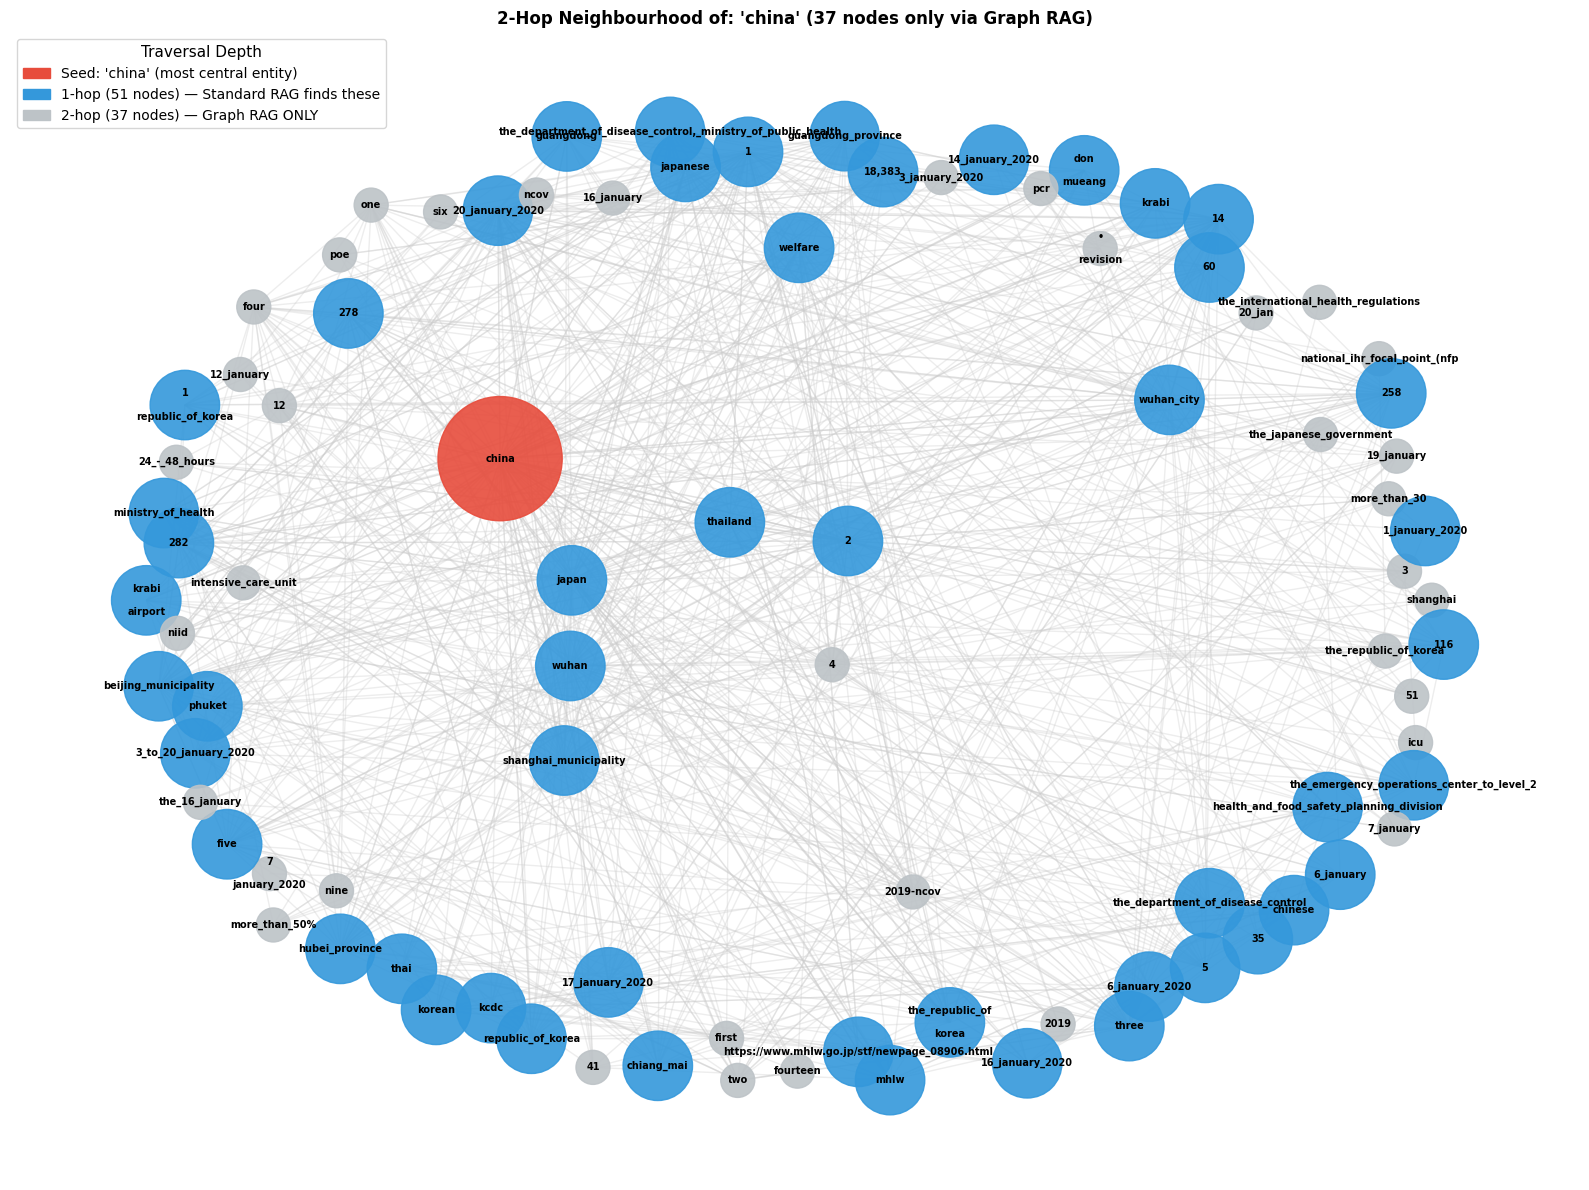

Saved: graph_rag_neighbourhood.png


In [8]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches

if G.number_of_nodes() == 0:
    print("No graph nodes — run Chapter 6 first")
else:
    top_node = sorted(nx.degree_centrality(G).items(),
                      key=lambda x: x[1], reverse=True)[0][0]

    ego  = nx.ego_graph(G, top_node, radius=2)
    hop1 = set(G.neighbors(top_node))
    hop2 = set(ego.nodes()) - hop1 - {top_node}

    print("=" * 60)
    print("2-HOP TRAVERSAL ANALYSIS")
    print("=" * 60)
    print()
    print(f"Seed entity      : '{top_node}'")
    print(f"1-hop neighbours : {len(hop1)}  ← Standard RAG finds these")
    print(f"2-hop subgraph   : {ego.number_of_nodes()} nodes total")
    print(f"2-hop ONLY nodes : {len(hop2)}  ← Graph RAG ONLY")
    print()
    print("Entities ONLY reachable via 2-hop traversal (Graph RAG advantage):")
    print("These would NEVER appear in standard dense+sparse search results")
    print("-" * 60)
    for n in sorted(hop2)[:20]:
        ntype = G.nodes[n].get("type", "?")
        print(f"  {n:<35} [{ntype}]")
    if len(hop2) > 20:
        print(f"  ... and {len(hop2) - 20} more")

    print()
    print("WHY THIS MATTERS:")
    print("  A query like 'Which countries linked to Wuhan had WHO regional offices?'")
    print("  requires: Wuhan → China → [country] → [WHO office]")
    print("  Steps 3 and 4 are invisible to standard RAG.")
    print("  Graph RAG traverses these edges to surface the complete answer.")

    # Visualise
    fig, ax = plt.subplots(figsize=(16, 12))
    pos = nx.spring_layout(ego, k=2.5, seed=42)

    color_map = []
    for n in ego.nodes():
        if n == top_node:     color_map.append("#E74C3C")
        elif n in hop1:       color_map.append("#3498DB")
        else:                 color_map.append("#BDC3C7")

    sizes = [
        8000 if n == top_node else
        2500 if n in hop1 else
        600
        for n in ego.nodes()
    ]

    nx.draw_networkx_edges(ego, pos, alpha=0.35, edge_color="#cccccc",
                           arrows=False, ax=ax)
    nx.draw_networkx_nodes(ego, pos, node_size=sizes,
                           node_color=color_map, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(ego, pos, font_size=7,
                            font_weight="bold", ax=ax)

    legend = [
        mpatches.Patch(color="#E74C3C",
                       label=f"Seed: '{top_node}' (most central entity)"),
        mpatches.Patch(color="#3498DB",
                       label=f"1-hop ({len(hop1)} nodes) — Standard RAG finds these"),
        mpatches.Patch(color="#BDC3C7",
                       label=f"2-hop ({len(hop2)} nodes) — Graph RAG ONLY"),
    ]
    ax.legend(handles=legend, loc="upper left", fontsize=10,
              title="Traversal Depth", title_fontsize=11)
    ax.set_title("2-Hop Neighbourhood of: " + repr(top_node) + " (" + str(len(hop2)) + " nodes only via Graph RAG)", fontsize=12, fontweight="bold")

    ax.axis("off")
    plt.tight_layout()
    plt.savefig("graph_rag_neighbourhood.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: graph_rag_neighbourhood.png")


---
# Chapter 11 — LLM Gateway Failover Demo

## Why this is in the Graph RAG notebook

The LLM Gateway is used throughout the pipeline:
- During parsing (vision model classifying figures)
- During ingestion (embedding API calls)
- During generation (chat completion for the answer)

If the gateway had a single provider and it went down at any of these points,
the entire pipeline would fail.

The demo below simulates Requesty going down and shows the gateway's health
tracking — including what happens when there is only one provider configured
(the app reports it clearly rather than silently breaking).

**To see a live failover to a second provider:**
Add `FIREWORKS_API_KEY=your-key` to `.env` and re-run.


In [9]:
from doc_intel_rag.gateway.llm_gateway import get_gateway
import asyncio

gw = get_gateway()

print("=" * 55)
print("LLM GATEWAY FAILOVER DEMO")
print("=" * 55)
print()
print("Active providers: " + str([p.name for p in gw.providers]))
print()

# Simulate primary going down
primary = gw.providers[0]
print(f"Step 1: Simulating '{primary.name}' failure (marking unhealthy)")
primary.failures = 3
primary.healthy  = False

print()
print("Step 2: Gateway health status:")
health = asyncio.get_event_loop().run_until_complete(gw.health())
for name, status in health.items():
    icon = "OK" if status["healthy"] else "DOWN"
    print(f"  [{icon}] {name:<15} healthy={status['healthy']}  failures={status['failures']}")

print()
if len(gw.providers) > 1:
    print("Step 3: Routing to fallback provider...")
    try:
        r = asyncio.get_event_loop().run_until_complete(gw.chat(
            model="alibaba/qwen-turbo",
            messages=[{"role": "user", "content": "Say FAILOVER SUCCESS in caps"}],
            max_tokens=10
        ))
        print("Response: " + r["choices"][0]["message"]["content"])
        print()
        print("Failover successful — application stayed online")
    except Exception as e:
        print("All providers failed: " + str(e))
else:
    print("Step 3: Only one provider configured.")
    print("  Add FIREWORKS_API_KEY to .env to see live failover.")
    print()
    print("Architecture with multiple providers:")
    print("  Requesty  (primary)   → DOWN")
    print("  Fireworks (secondary) → tries this")
    print("  Novita    (tertiary)  → tries this if Fireworks also fails")
    print()
    print("All of this happens in milliseconds, transparently to the caller.")

# Restore
primary.healthy  = True
primary.failures = 0
print()
print("Step 4: Primary provider restored.")
print("  healthy=True, failures=0 — back in rotation automatically.")


LLM GATEWAY FAILOVER DEMO

Active providers: ['requesty']

Step 1: Simulating 'requesty' failure (marking unhealthy)

Step 2: Gateway health status:
  [DOWN] requesty        healthy=False  failures=3

Step 3: Only one provider configured.
  Add FIREWORKS_API_KEY to .env to see live failover.

Architecture with multiple providers:
  Requesty  (primary)   → DOWN
  Fireworks (secondary) → tries this
  Novita    (tertiary)  → tries this if Fireworks also fails

All of this happens in milliseconds, transparently to the caller.

Step 4: Primary provider restored.
  healthy=True, failures=0 — back in rotation automatically.


---
# Summary — What You Just Ran

## The complete Graph RAG pipeline in one picture

```
WHO COVID-19 PDF
       │
       ▼
[GLM-OCR Hybrid Parser]
  PyMuPDF → text spans (paragraph, title)
  Vision LLM → image classification (medical_scan, chart, diagram)
  find_tables() → table extraction with HTML structure
       │
       ▼  284 elements
[Document-Aware Chunker]
  Atomic: tables (never split), images (never split)
  Text: accumulated up to 512 tokens with 64-token overlap
       │
       ▼  15 chunks (text=9, table=5, image=1)
[spaCy NER + Graph Extractor]
  Extract named entities: China, WHO, Thailand, dates, counts
  Build co-occurrence edges between entities in same chunk
       │
       ▼  107 nodes, 923 edges
[Three-Vector Embedder via LLM Gateway]
  text_dense  (1536-dim, Requesty → openai/text-embedding-3-small)
  bm25_sparse (CPU-only keyword hashing)
  graph_dense (128-dim node2vec from knowledge graph)
       │
       ▼
[Qdrant]  ← all 15 chunks stored with 3 vectors each
       │
       ▼  at query time
[Hybrid RRF Searcher]
  Dense search + Sparse BM25 + 2-hop Graph Traversal → fused ranking
       │
[Cohere Reranker] → cross-encoder scoring
       │
[Groundedness Scorer] → 0.45 threshold
       │
[LLM Generator] → answer with [Source N] citations
```

## What makes this better than the main branch

| Aspect | main branch | dev branch |
|--------|-------------|------------|
| Parser | PyMuPDF only | GLM-OCR hybrid (35 entity types) |
| Image labels | Generic "figure" | medical_scan / chart / diagram |
| LLM routing | Single provider | Gateway with failover |
| Relational queries | Basic keyword match | 2-hop graph traversal |
| Scanned page support | Vision flag | Integrated into parser |
